## Data Retrieval

In [2]:
import os
import glob
import pandas as pd

In [3]:
def _csv_instrument_key(path):
	basename = os.path.splitext(os.path.basename(path))[0]
	if "_" in basename:
		return basename.split("_", 1)[0]
	return basename


def load_csvs_from_folder(folder_path="data"):
	"""Recursively load all CSV files under `folder_path` into a dict of DataFrames.

	Keys are the instrument names derived from the CSV filenames.
	For example, `CRUDEOILM_historical_data.csv` becomes `CRUDEOILM`.

	Returns:
		dict: {instrument_name: pandas.DataFrame}
	"""
	folder = os.path.abspath(folder_path)
	if not os.path.isdir(folder):
		raise FileNotFoundError(f"Folder not found: {folder}")

	# Find CSVs recursively
	csv_paths = sorted(glob.glob(os.path.join(folder, "**", "*.csv"), recursive=True))
	dataframes = {}
	for path in csv_paths:
		key = _csv_instrument_key(path)
		try:
			# Detect if a 'date' column exists (case-insensitive) and parse it
			header_cols = pd.read_csv(path, nrows=0).columns.tolist()
			lower_cols = [c.lower() for c in header_cols]
			parse_dates = [header_cols[i] for i, c in enumerate(lower_cols) if c == 'date'] or None
			if parse_dates:
				df = pd.read_csv(path, parse_dates=parse_dates)
			else:
				df = pd.read_csv(path)
			dataframes[key] = df
		except Exception as e:
			print(f"Failed to load {path}: {e}")
	return dataframes


def load_req_csvs(folder_path="data", instruments=None):
	"""Load only CSVs whose file name matches one of the provided instruments.

	Args:
		folder_path (str): root folder to search (recursively).
		instruments (list[str]): list of instrument names to filter by. Matching is
			case-insensitive and checks if an instrument string appears anywhere in
			the CSV filename, such as `CRUDEOILM_historical_data.csv`.

	Returns:
		dict: {instrument_name: pandas.DataFrame} for matching files.
	"""
	if not instruments:
		raise ValueError("`instruments` must be a non-empty list of instrument names")

	# normalize instruments for case-insensitive matching
	inst_upper = [str(i).upper() for i in instruments]

	folder = os.path.abspath(folder_path)
	if not os.path.isdir(folder):
		raise FileNotFoundError(f"Folder not found: {folder}")

	csv_paths = sorted(glob.glob(os.path.join(folder, "**", "*.csv"), recursive=True))
	dataframes = {}
	for path in csv_paths:
		key = _csv_instrument_key(path)
		key_upper = key.upper()

		# include file if any instrument name is found in the CSV filename
		if not any(inst in key_upper for inst in inst_upper):
			continue

		try:
			header_cols = pd.read_csv(path, nrows=0).columns.tolist()
			lower_cols = [c.lower() for c in header_cols]
			parse_dates = [header_cols[i] for i, c in enumerate(lower_cols) if c == 'date'] or None
			if parse_dates:
				df = pd.read_csv(path, parse_dates=parse_dates)
			else:
				df = pd.read_csv(path)
			dataframes[key] = df
		except Exception as e:
			print(f"Failed to load {path}: {e}")

	return dataframes


def filter_close_price(df):
	"""Filter the DataFrame to include only 'date' and 'close' columns, if they exist."""
	cols = df.columns.str.lower()
	date_col = df.columns[cols == 'date'][0] if 'date' in cols else None
	close_col = df.columns[cols == 'close'][0] if 'close' in cols else None

	if date_col and close_col:
		return df[[date_col, close_col]].rename(columns={date_col: 'date', close_col: 'close'})
	else:
		print("Warning: 'date' or 'close' column not found. Returning original DataFrame.")
		return df

In [4]:
dfs = load_req_csvs("data", instruments=['NIFTY', 'BANKNIFTY', 'CRUDEOILM', 'GOLDGUINEA', 'NATGASMINI', 'SILVERMIC', 'USDINR', 'EURINR'])
print(f"Loaded {len(dfs)} CSVs: {list(dfs.keys())}")


for key in dfs:
    dfs[key] = filter_close_price(dfs[key])

dfs['NIFTY'].head()

Loaded 11 CSVs: ['EURINR', 'USDINR', 'CRUDEOILM', 'GOLDGUINEA', 'NATGASMINI', 'SILVERMIC', 'BANKNIFTY', 'FINNIFTY', 'MIDCPNIFTY', 'NIFTYNXT50', 'NIFTY']


,date,close
0,2021-05-28 00:00:00+05:30,15463.85
1,2021-05-31 00:00:00+05:30,15583.20
2,2021-06-01 00:00:00+05:30,15618.15
3,2021-06-02 00:00:00+05:30,15616.75
4,2021-06-03 00:00:00+05:30,15712.40


## Backadjustment

In [5]:
import calendar

Below function backadjusts data keeping rollover as a fixed date (Eg: 17th of every month). This is useful for MCX market contracts

In [6]:
def backadjust_expiry_date(df, rollover_day, date_col="date", price_col="close", adj_col="close_adj"):
    """
    Add additive back-adjustment on the given rollover day.
    If the rollover day is a holiday, the previous available trading date is used.
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col]).dt.tz_localize(None).dt.normalize()
    df = df.sort_values(date_col).reset_index(drop=True)
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

    if df.empty:
        return df

    available_dates = set(df[date_col])
    df["adj_offset"] = 0.0

    months = sorted({(d.year, d.month) for d in df[date_col]})
    for year, month in months:
        target_day = min(rollover_day, calendar.monthrange(year, month)[1])
        target = pd.Timestamp(year, month, target_day)

        if target > df[date_col].max():
            continue

        if target in available_dates:
            rollover_date = target
        else:
            prior = df[df[date_col] < target]
            if prior.empty:
                continue
            rollover_date = prior[date_col].max()

        idx = df.index[df[date_col] == rollover_date]
        if len(idx) == 0:
            continue
        idx = idx[0]
        if idx == 0:
            continue

        gap = df.at[idx, price_col] - df.at[idx - 1, price_col]
        df.loc[: idx - 1, "adj_offset"] += gap

    df[adj_col] = df[price_col] - df["adj_offset"]
    return df.drop(columns=["adj_offset"])

This function backadjusts data keeping the last given weekday as the expiry day (Eg: Last thursday of every month). This is useful for NFO contracts.

In [7]:
def _normalize_datetime_series(series):
    dt = pd.to_datetime(series, errors="coerce")
    if getattr(dt.dt, "tz", None) is not None:
        try:
            dt = dt.dt.tz_convert(None)
        except TypeError:
            dt = dt.dt.tz_localize(None)
    return dt.dt.tz_localize(None).dt.normalize()



In [13]:
def _parse_expiry_day(expiry_day):
    """Parse expiry day string like 'last thursday' and return (nth, weekday_idx).
    
    Args:
        expiry_day (str): e.g., 'last thursday', '1st monday', '3rd friday'
    
    Returns:
        tuple: (nth, weekday_idx) where nth is -1 for 'last', 1+ for ordinal, 
               and weekday_idx is 0-6 (Monday-Sunday)
    """
    parts = expiry_day.lower().strip().split()
    
    # Determine the nth value
    if parts[0] == 'last':
        nth = -1
    elif parts[0] in ['1st', '2nd', '3rd', '4th', '5th']:
        nth_map = {'1st': 1, '2nd': 2, '3rd': 3, '4th': 4, '5th': 5}
        nth = nth_map.get(parts[0], 1)
    else:
        raise ValueError(f"Invalid expiry day format: {expiry_day}")
    
    # Determine the weekday index (Monday=0, ..., Sunday=6)
    weekday_str = parts[-1].lower()
    weekday_map = {
        'monday': 0, 'tuesday': 1, 'wednesday': 2, 'thursday': 3,
        'friday': 4, 'saturday': 5, 'sunday': 6
    }
    
    weekday_idx = weekday_map.get(weekday_str)
    if weekday_idx is None:
        raise ValueError(f"Invalid weekday in expiry day: {weekday_str}")
    
    return nth, weekday_idx


def _month_expiry_date(year, month, weekday_idx, nth):
    """Return the date of the nth occurrence of a weekday in a given month.
    
    Args:
        year: year
        month: month (1-12)
        weekday_idx: weekday index (0=Monday, ..., 6=Sunday)
        nth: positive for "1st, 2nd, ..." or -1 for "last"
    
    Returns:
        datetime.date: The expiry date
    """
    import datetime
    
    if nth > 0:
        # Find the nth occurrence from the start
        first_day = datetime.date(year, month, 1)
        days_ahead = (weekday_idx - first_day.weekday()) % 7
        date = first_day + datetime.timedelta(days=days_ahead + (nth - 1) * 7)
        return date
    else:  # nth < 0 (e.g., -1 for "last")
        # Find from the end of the month
        last_day = calendar.monthrange(year, month)[1]
        last_date = datetime.date(year, month, last_day)
        days_back = (last_date.weekday() - weekday_idx) % 7
        date = last_date - datetime.timedelta(days=days_back)
        # Go back further for -2, -3, etc.
        for _ in range(-nth - 1):
            date -= datetime.timedelta(days=7)
        return date


In [8]:
def backadjust_expiry_fixed_day(df, expiry_day, date_col="date", price_col="close", adj_col="close_adj"):
    """Additive back-adjustment using a monthly expiry rule like 'last thursday'."""
    df = df.copy()
    df[date_col] = _normalize_datetime_series(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

    if df.empty:
        return df

    nth, weekday_idx = _parse_expiry_day(expiry_day)
    available_dates = set(df[date_col])
    df["adj_offset"] = 0.0

    months = sorted({(d.year, d.month) for d in df[date_col]})
    for year, month in months:
        expiry_date = _month_expiry_date(year, month, weekday_idx, nth)
        expiry_date = pd.Timestamp(expiry_date)
        if expiry_date.tzinfo is not None:
            expiry_date = expiry_date.tz_convert(None)
        expiry_date = expiry_date.normalize()
        if expiry_date > df[date_col].max():
            continue

        if expiry_date in available_dates:
            rollover_date = expiry_date
        else:
            prior = df[df[date_col] < expiry_date]
            if prior.empty:
                continue
            rollover_date = prior[date_col].max()

        idx = df.index[df[date_col] == rollover_date]
        if len(idx) == 0 or idx[0] == 0:
            continue

        idx = idx[0]
        gap = df.at[idx, price_col] - df.at[idx - 1, price_col]
        df.loc[: idx - 1, "adj_offset"] += gap

    df[adj_col] = df[price_col] - df["adj_offset"]
    return df.drop(columns=["adj_offset"])


This function keeps the expiry day as two days before the last trading day of every month. This is useful for CDS contracts.

In [19]:
def backadjust_n_days_before_last(df, n_days_before_last=2, date_col="date", price_col="close", adj_col="close_adj"):
    """Additive back-adjustment using the n-th trading day before the last trading day of each month.

    Args:
        df: input DataFrame containing date and price columns.
        n_days_before_last: 0 means last trading day, 1 means second-to-last, 2 means third-to-last, etc.
        date_col: name of the date column.
        price_col: name of the price column.
        adj_col: output adjusted price column.
    """
    if n_days_before_last < 0:
        raise ValueError("n_days_before_last must be >= 0")

    df = df.copy()
    df[date_col] = _normalize_datetime_series(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

    if df.empty:
        return df

    df["adj_offset"] = 0.0
    grouped = df.groupby([df[date_col].dt.year, df[date_col].dt.month])

    for (year, month), group in grouped:
        if len(group) <= n_days_before_last:
            continue

        target_date = group[date_col].nlargest(n_days_before_last + 1).iloc[-1]
        idx = df.index[df[date_col] == target_date]
        if len(idx) == 0 or idx[0] == 0:
            continue

        idx = idx[0]
        gap = df.at[idx, price_col] - df.at[idx - 1, price_col]
        df.loc[: idx - 1, "adj_offset"] += gap

    df[adj_col] = df[price_col] - df["adj_offset"]
    return df.drop(columns=["adj_offset"])


In [17]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'NIFTY Back-Adjusted Close Price'}, xlabel='date'>

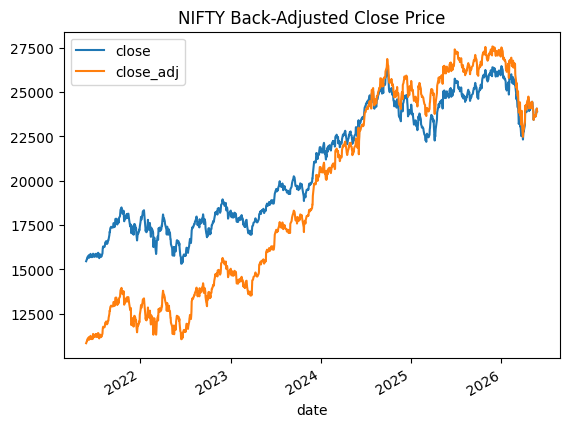

In [15]:
nifty_backadj = backadjust_expiry_fixed_day(dfs['NIFTY'], expiry_day="last thursday")

nifty_backadj.plot(x="date", y=["close", "close_adj"], title="NIFTY Back-Adjusted Close Price")

<Axes: title={'center': 'CRUDEOILM Back-Adjusted Close Price'}, xlabel='date'>

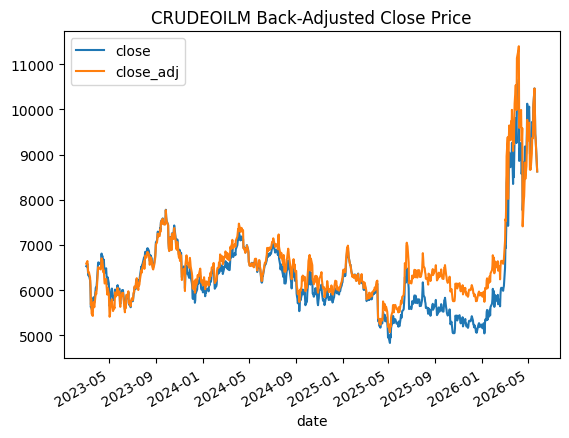

In [21]:
crudeoil_backadj = backadjust_expiry_date(dfs['CRUDEOILM'], rollover_day=17)

crudeoil_backadj.plot(x="date", y=["close", "close_adj"], title="CRUDEOILM Back-Adjusted Close Price")

<Axes: title={'center': 'USDINR Back-Adjusted Close Price'}, xlabel='date'>

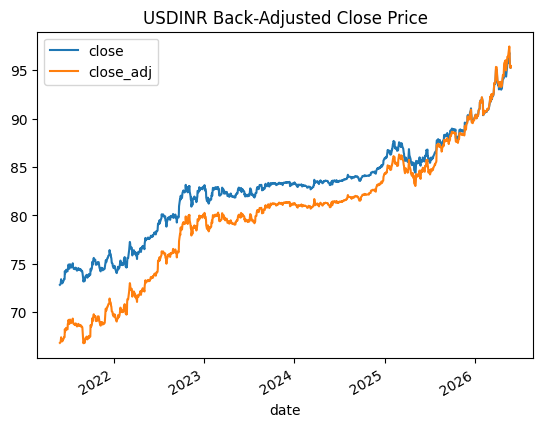

In [22]:
usdinr_backadj = backadjust_n_days_before_last(dfs['USDINR'], n_days_before_last=2)

usdinr_backadj.plot(x="date", y=["close", "close_adj"], title="USDINR Back-Adjusted Close Price")